In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
# Dark Mode Plots
plt.style.use('dark_background')
import corner
import ast

In [81]:
# Make the corner plot for the MCMC results
system_name = 'J1537'
model_ver = 'sie'
mcmc_samples_path = f'../{system_name}/mcmc/{model_ver}_mcmc.dat'
samples = pd.read_csv(mcmc_samples_path, delim_whitespace=True, header=None, names=['chi2', 'vel_disp', 'x', 'y', 'ellip', 'pa' ])


In [82]:
samples

,chi2,vel_disp,x,y,ellip,pa
0,3.431897,312.5116,-1.437815,0.702070,0.599435,-30.29098
1,4.110201,312.5514,-1.438579,0.701416,0.599409,-30.36948
2,6.586287,312.6091,-1.440065,0.704702,0.602485,-30.37422
3,8.025789,312.3671,-1.436132,0.696166,0.602534,-30.29843
4,8.633006,312.0801,-1.443969,0.693921,0.595773,-30.34064
...,...,...,...,...,...,...
2011,12.404000,312.1549,-1.428123,0.717448,0.597604,-30.34484
2012,9.211721,311.9130,-1.432751,0.711013,0.594140,-30.37097
2013,9.205030,312.3127,-1.442015,0.705884,0.593931,-30.36173
2014,7.832772,312.2502,-1.440323,0.699352,0.591720,-30.38388


In [83]:
masked_samples = samples.drop(columns=['chi2']).to_numpy()

In [84]:
# # Masked Samples with no accept column
# masked_samples = samples[samples['accept'] == 'accept'].copy()
# masked_samples = masked_samples.drop(columns=['accept', 'chi2']).to_numpy()
# masked_samples

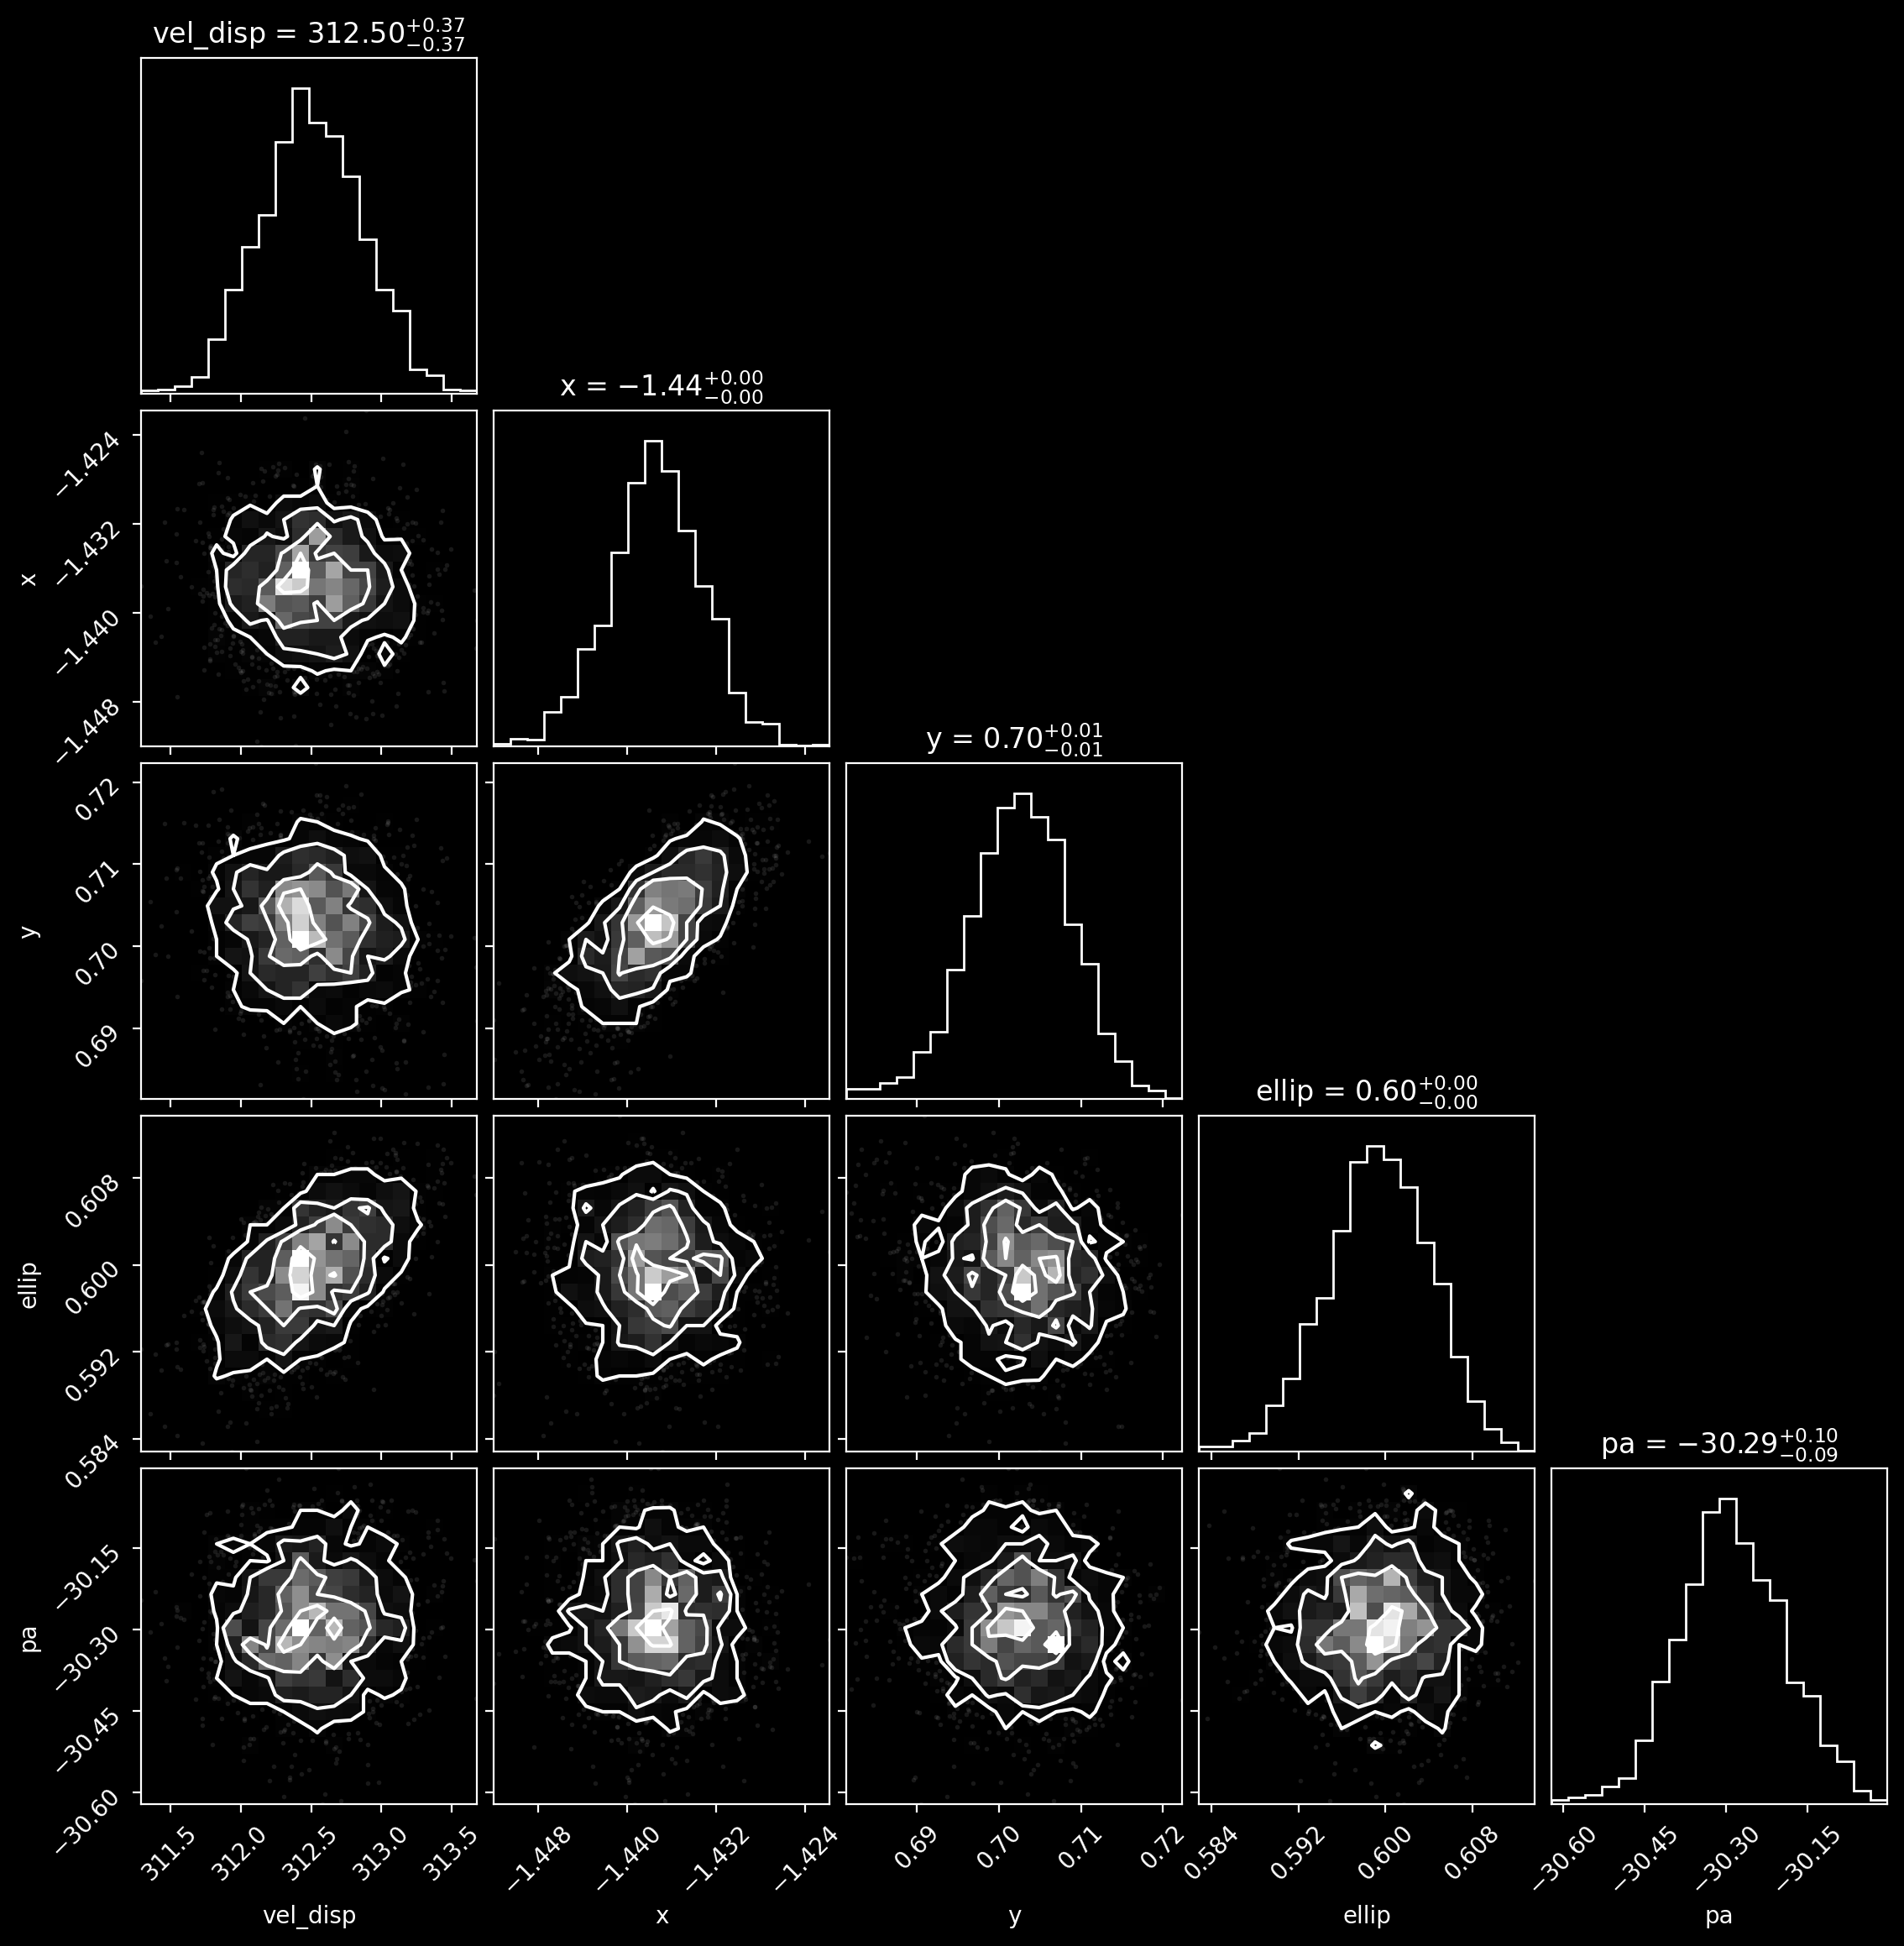

In [85]:
# Remove the first column when loading the samples, as it is the accepted/rejected column
labels = ['vel_disp', 'x', 'y', 'ellip', 'pa']
fig = corner.corner(masked_samples, labels=labels, show_titles=True)
plt.savefig(f'../{system_name}/mcmc/{model_ver}_corner.png')